### KALIBRASI


analisis gap hasil kalibrasi


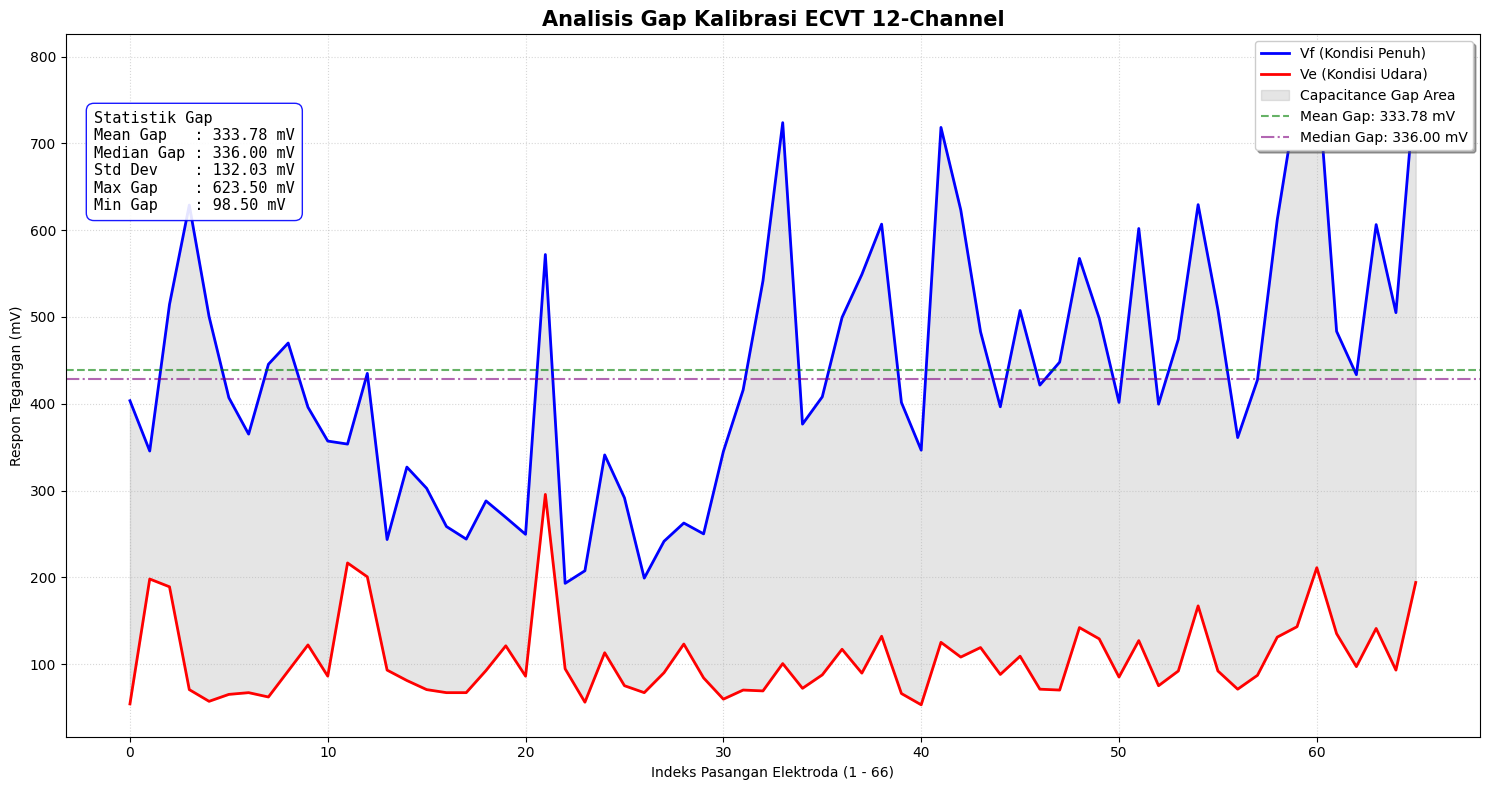

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_enhanced_gap_analysis_12ch(file_path):
    try:
        # 1. Loading Data
        mat_data = scipy.io.loadmat(file_path)
        
        # Mengekstrak dari struct 'bes' (Struktur khusus file 12ch Anda)
        bes = mat_data['bes'][0, 0]
        ve = bes['Ve'].flatten() # Data Udara
        vf = bes['Vf'].flatten() # Data Air
        
        # Penanganan Indeks (Sesuai jumlah data: 66)
        indices = np.arange(len(ve))
            
        # --- PERHITUNGAN STATISTIK GAP ---
        # Gap biasanya didefinisikan sebagai (Vf - Ve)
        gap = vf - ve
        mean_gap = np.mean(gap)
        median_gap = np.median(gap) 
        std_gap = np.std(gap)
        max_gap = np.max(gap)
        min_gap = np.min(gap)

        # 2. Plotting
        plt.figure(figsize=(15, 8))
        
        # Plot Garis Vf dan Ve
        plt.plot(indices, vf, label='Vf (Kondisi Penuh)', color='blue', linewidth=2)
        plt.plot(indices, ve, label='Ve (Kondisi Udara)', color='red', linewidth=2)
        
        # Arsir Gap area
        plt.fill_between(indices, ve, vf, color='gray', alpha=0.2, label='Capacitance Gap Area')

        # Garis Horizontal Statistik
        plt.axhline(y=np.mean(ve) + mean_gap, color='green', linestyle='--', alpha=0.6, 
                    label=f'Mean Gap: {mean_gap:.2f} mV')
        plt.axhline(y=np.median(ve) + median_gap, color='purple', linestyle='-.', alpha=0.6, 
                    label=f'Median Gap: {median_gap:.2f} mV')

        # 3. Styling & Annotations
        plt.title(f'Analisis Gap Kalibrasi ECVT 12-Channel', fontweight='bold', fontsize=15)
        plt.xlabel('Indeks Pasangan Elektroda (1 - 66)')
        plt.ylabel('Respon Tegangan (mV)')
        
        # Box Statistik
        stats_box = (
            f"Statistik Gap\n"
            f"Mean Gap   : {mean_gap:.2f} mV\n"
            f"Median Gap : {median_gap:.2f} mV\n"
            f"Std Dev    : {std_gap:.2f} mV\n"
            f"Max Gap    : {max_gap:.2f} mV\n"
            f"Min Gap    : {min_gap:.2f} mV"
        )
        
        plt.annotate(stats_box, xy=(0.02, 0.75), xycoords='axes fraction', 
                     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="blue", alpha=0.9),
                     fontsize=11, family='monospace')

        plt.legend(loc='upper right', frameon=True, shadow=True)
        plt.grid(True, which='both', linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Jalankan fungsi dengan path file Anda
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
plot_enhanced_gap_analysis_12ch(file_path)

grafik linearitas


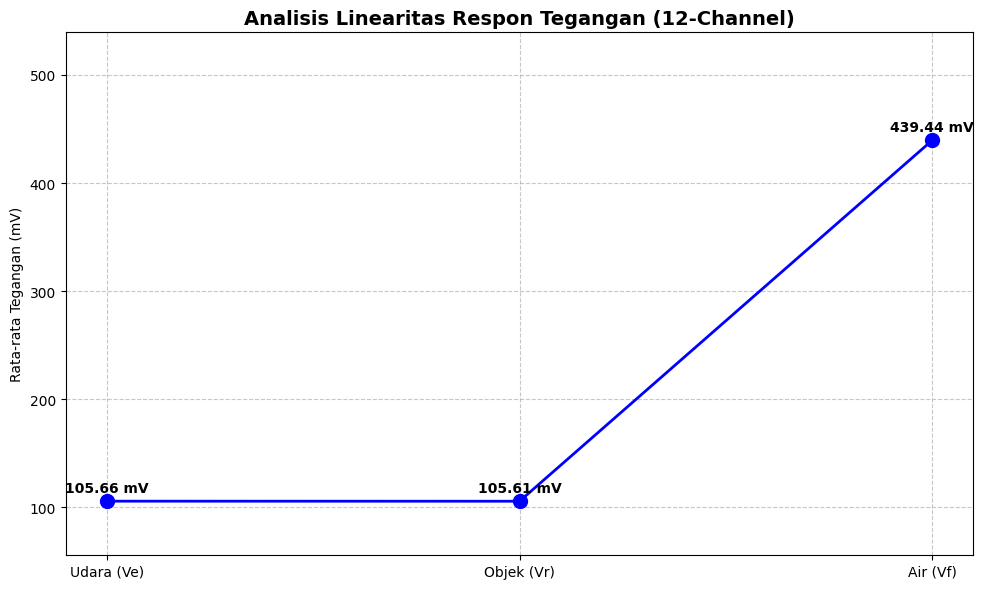

In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_linearity_12ch(file_path):
    try:
        # 1. Loading Data
        data = scipy.io.loadmat(file_path)
        
        # Masuk ke struct 'bes' 
        bes = data['bes'][0, 0]
        
        # Ekstrak data (Pastikan nama key sesuai output: Ve, Vf, Vrt) 
        ve = bes['Ve'].flatten()      # Udara
        vf = bes['Vf'].flatten()      # Air (Penuh)
        vrt = bes['Vrt']             # Objek (Matriks 25 frame)
        
        # 2. Hitung Rata-rata Tegangan Global
        # Untuk Vrt, kita ambil rata-rata dari seluruh frame dan seluruh elektroda
        ve_avg = np.mean(ve)
        vf_avg = np.mean(vf)
        vr_avg = np.mean(vrt)
        deviasi = abs(vr_avg - ve_avg)
        deviasi_persen = (deviasi / (vf_avg - ve_avg)) * 100
        
        # 3. Plotting
        plt.figure(figsize=(10, 6))
        
        labels = ['Udara (Ve)', 'Objek (Vr)', 'Air (Vf)']
        values = [ve_avg, vr_avg, vf_avg]
    
        
        # Membuat grafik garis linearitas
        plt.plot(labels, values, marker='o', markersize=10, linewidth=2, color='blue', label='Respon Sensor')
        
        # Tambahkan Label Nilai di Setiap Titik
        for i, v in enumerate(values):
            plt.text(i, v + (max(values)*0.02), f'{v:.2f} mV', ha='center', fontweight='bold')

        plt.title('Analisis Linearitas Respon Tegangan (12-Channel)', fontsize=14, fontweight='bold')
        plt.ylabel('Rata-rata Tegangan (mV)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ylim(min(values) - 50, max(values) + 100)
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error Terdeteksi: {e}")

# Masukkan path file Anda di sini
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
plot_linearity_12ch(file_path)

analisis gap & stabilitas (noise)


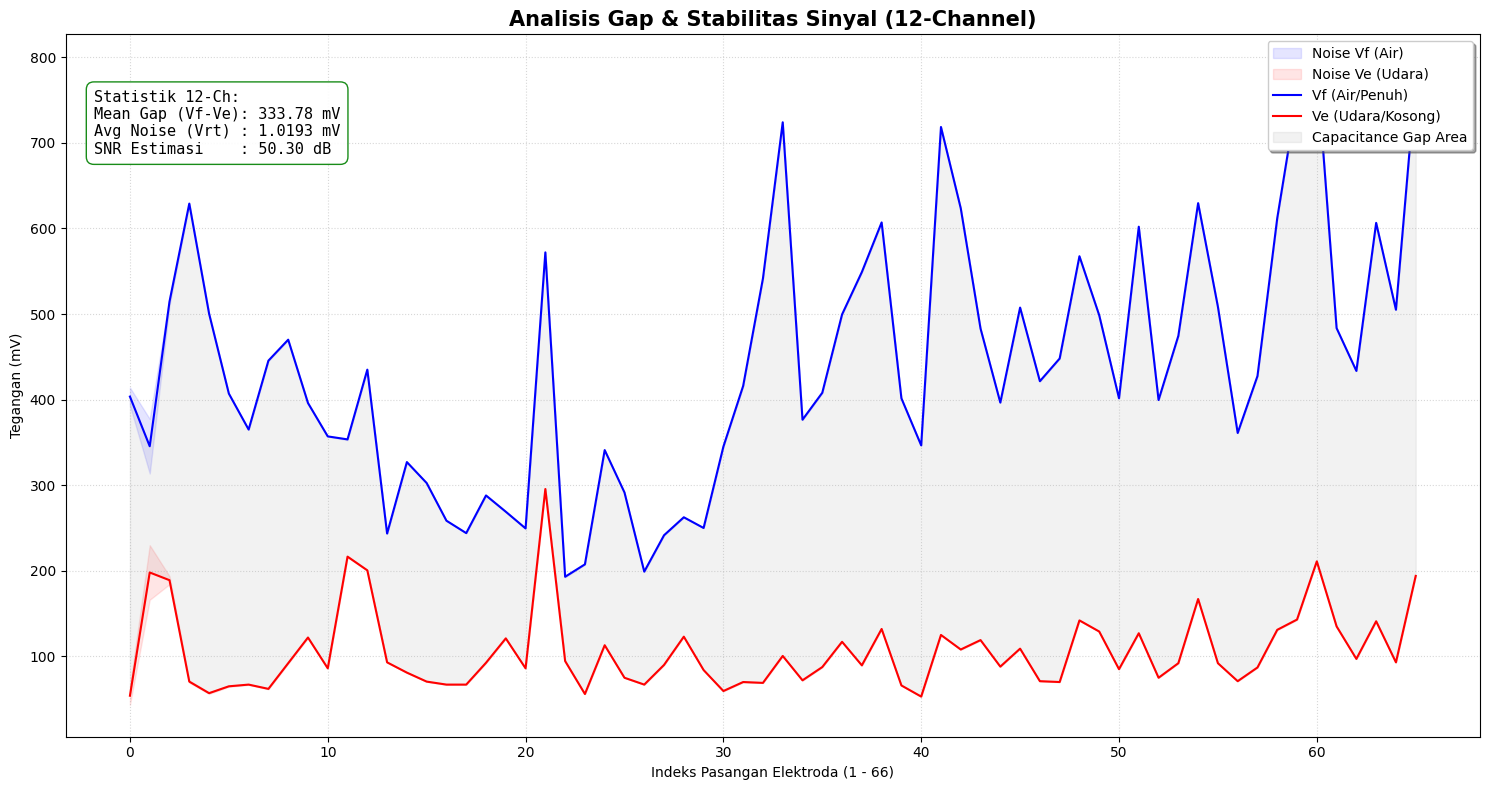

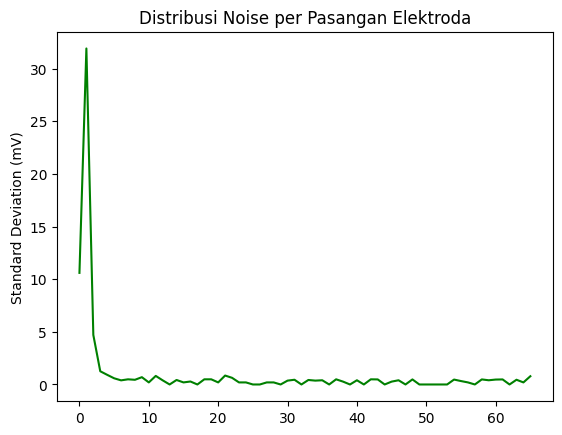

In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_gap_noise_12ch(file_path):
    try:
        # 1. Loading Data
        data = scipy.io.loadmat(file_path)
        bes = data['bes'][0, 0]
        
        # Ekstrak Data
        ve = bes['Ve'].flatten()      # Rata-rata Udara (Baseline)
        vf = bes['Vf'].flatten()      # Rata-rata Air (Referensi)
        vrt = bes['Vrt']             # Data mentah (25 frame x 66 pasangan)
        
        indices = np.arange(len(ve)) # 0 - 65
        
        # 2. Hitung Mean dan Noise (Std Dev) dari Vrt
        vr_mean = np.mean(vrt, axis=0)
        vr_std = np.std(vrt, axis=0) # Inilah fluktuasi/noise saat pengukuran
        #ve_std = np.std(ve)          # Noise Ve
        #vf_std = np.std(vf)          # Noise Vf
        
        gap_total = vf - ve
        mean_gap = np.mean(gap_total)

        # 3. Plotting
        plt.figure(figsize=(15, 8))
        
        # Plot Area Noise pada data objek (Vrt)
        #plt.fill_between(indices, vr_mean - vr_std, vr_mean + vr_std, 
                        # color='green', alpha=0.3, label='Noise Objek (Vrt Std Dev)')
        #plot area noise udara dan air
        plt.fill_between(indices, vf - vr_std, vf + vr_std, color='blue', alpha=0.1, label='Noise Vf (Air)')
        plt.fill_between(indices, ve - vr_std, ve + vr_std, color='red', alpha=0.1, label='Noise Ve (Udara)')
        
        # Garis Utama
        plt.plot(indices, vf, label='Vf (Air/Penuh)', color='blue', linewidth=1.5, linestyle='-')
        plt.plot(indices, ve, label='Ve (Udara/Kosong)', color='red', linewidth=1.5, linestyle='-')
        #plt.plot(indices, vr_mean, label='Vr (Objek - Mean)', color='green', linewidth=2)
        
        # Arsir Wilayah Gap Kalibrasi
        plt.fill_between(indices, ve, vf, color='gray', alpha=0.1, label='Capacitance Gap Area')

        # 4. Styling
        plt.title('Analisis Gap & Stabilitas Sinyal (12-Channel)', fontweight='bold', fontsize=15)
        plt.xlabel('Indeks Pasangan Elektroda (1 - 66)')
        plt.ylabel('Tegangan (mV)')
        
        # Info Box
        avg_noise = np.mean(vr_std)
        stats_box = (
            f"Statistik 12-Ch:\n"
            f"Mean Gap (Vf-Ve): {mean_gap:.2f} mV\n"
            f"Avg Noise (Vrt) : {avg_noise:.4f} mV\n"
            f"SNR Estimasi    : {20*np.log10(mean_gap/avg_noise):.2f} dB"
        )
        plt.annotate(stats_box, xy=(0.02, 0.83), xycoords='axes fraction', 
                     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="green", alpha=0.9),
                     fontsize=11, family='monospace')

        plt.legend(loc='upper right', frameon=True, shadow=True)
        plt.grid(True, which='both', linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

        plt.figure()
        plt.plot(indices, vr_std, color='green')
        plt.title('Distribusi Noise per Pasangan Elektroda')
        plt.ylabel('Standard Deviation (mV)')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Jalankan
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
plot_gap_noise_12ch(file_path)

persebaran titik channel aktif


Total Pasangan: 66
Valid: 66, Tereliminasi: 0


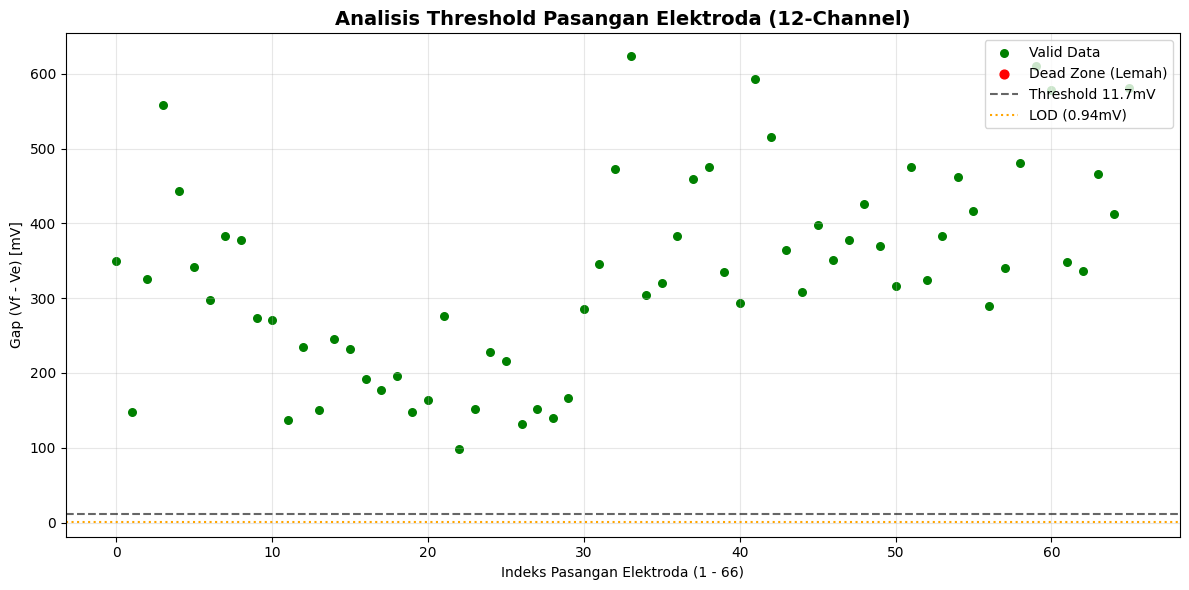

In [4]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def analyze_gap_12ch(file_path, threshold=11.7):
    try:
        # 1. Load Data dari struct 'bes'
        mat_data = scipy.io.loadmat(file_path)
        bes = mat_data['bes'][0, 0]
        
        # Ekstrak Ve dan Vf (12-ch biasanya hanya 1 frekuensi)
        ve = bes['Ve'].flatten() 
        vf = bes['Vf'].flatten()
        
        indices = np.arange(len(ve)) # 0 sampai 65
        gap = vf - ve # Menghitung selisih sensitivitas
        
        # 2. Identifikasi Dead Zone
        dead_mask = gap < threshold
        alive_mask = ~dead_mask
        
        # 3. Plotting
        plt.figure(figsize=(12, 6))
        
        # Plot titik data yang valid (Hijau) dan yang di bawah threshold (Merah)
        plt.scatter(indices[alive_mask], gap[alive_mask], color='green', s=30, label='Valid Data')
        plt.scatter(indices[dead_mask], gap[dead_mask], color='red', s=40, label='Dead Zone (Lemah)')
        
        # Garis bantu Threshold dan LOD
        plt.axhline(y=threshold, color='black', linestyle='--', alpha=0.6, label=f'Threshold {threshold}mV')
        plt.axhline(y=0.94, color='orange', linestyle=':', label='LOD (0.94mV)')
        
        plt.title('Analisis Threshold Pasangan Elektroda (12-Channel)', fontweight='bold', fontsize=14)
        plt.xlabel('Indeks Pasangan Elektroda (1 - 66)')
        plt.ylabel('Gap (Vf - Ve) [mV]')
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right')
        
        # Print ringkasan di konsol
        print(f"Total Pasangan: {len(ve)}")
        print(f"Valid: {np.sum(alive_mask)}, Tereliminasi: {np.sum(dead_mask)}")
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}. Pastikan file menggunakan format struct 'bes'.")

# Jalankan
file_path = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
analyze_gap_12ch(file_path, threshold=11.7)

standar deviasi, LOD, dan LOQ


File breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat sukses.
File breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat sukses.
File breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat sukses.
File breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat sukses.
File breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat sukses.

     Sistem  Sigma  LOD(3σ)  LOQ(10σ)  (11σ)  SNR(dB)  Noise_Contr(%) Status
12ch Das 2   1.06     3.18     10.59  11.65    49.97            9.05  VALID


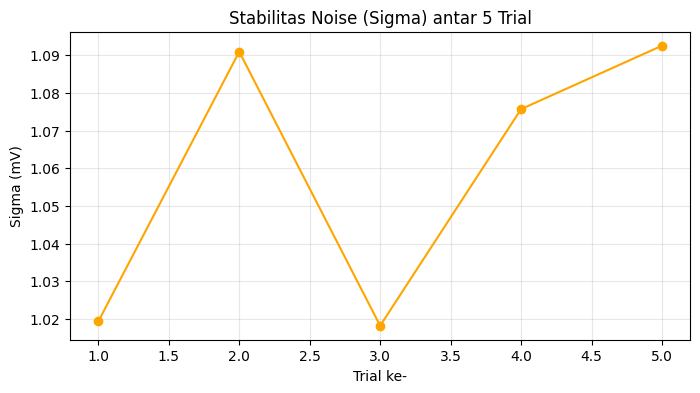

In [5]:
import scipy.io
import numpy as np
import pandas as pd
import os

# 1. KONFIGURASI (Sesuaikan dengan file 12-ch Anda)
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat'
]
THRESHOLD_AWAL = 11.7  # Sesuai analisis gap sebelumnya

all_stats = []

for f_path in FILE_PATHS:
    try:
        mat = scipy.io.loadmat(f_path)
        bes = mat['bes'][0, 0]
        
        # Ekstrak data 12-ch
        ve_mean = bes['Ve'].flatten()
        vf_mean = bes['Vf'].flatten()
        vrt_raw = bes['Vrt'] # Bentuk: (25 frame, 66 pasangan)
        
        # Hitung Sigma Temporal (Noise) dari 25 frame
        std_per_ch = np.std(vrt_raw, axis=0) # Std dev per pasangan
        sigma_aktual = np.mean(std_per_ch) 
        
        gap = vf_mean - ve_mean
        is_alive = gap > THRESHOLD_AWAL
        sig_mean = np.mean(gap[is_alive]) if np.any(is_alive) else 0
        
        all_stats.append({
            'sigma': sigma_aktual,
            'gap_mean': sig_mean,
            'dz': np.sum(~is_alive)
        })
        print(f"File {os.path.basename(f_path)} sukses.")
    except Exception as e:
        print(f"Error pada {f_path}: {e}")

# 3. AGREGASI METROLOGI
# Karena hanya 1 frekuensi, kita langsung hitung dari all_stats
avg_sigma = np.mean([t['sigma'] for t in all_stats])
avg_gap = np.mean([t['gap_mean'] for t in all_stats])
avg_dz = np.mean([t['dz'] for t in all_stats])

# Metrologi IUPAC
lod = 3 * avg_sigma
loq = 10 * avg_sigma
snr_db = 20 * np.log10(avg_gap / avg_sigma) if avg_gap > 0 else 0
noise_contr = (avg_sigma / THRESHOLD_AWAL) * 100

# Penentuan Status
if noise_contr <= 7: status = "HIGH FIDELITY"
elif noise_contr <= 10: status = "VALID"
else: status = "UNSTABLE"

# Tampilkan Hasil dalam 1 Baris (karena 1 frekuensi)
final_result = {
    'Sistem': '12ch Das 2',
    'Sigma': round(avg_sigma, 2),
    'LOD(3σ)': round(lod, 2),
    'LOQ(10σ)': round(loq, 2),
    '(11σ)' :   round(11*avg_sigma, 2),
    'SNR(dB)': round(snr_db, 2),
    'Noise_Contr(%)': round(noise_contr, 2),
    'Status':status
}

print("\n", pd.DataFrame([final_result]).to_string(index=False))

import matplotlib.pyplot as plt

# Tambahkan ini setelah loop trial selesai
sigmas = [t['sigma'] for t in all_stats]
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), sigmas, marker='o', linestyle='-', color='orange')
plt.title('Stabilitas Noise (Sigma) antar 5 Trial')
plt.xlabel('Trial ke-')
plt.ylabel('Sigma (mV)')
plt.grid(True, alpha=0.3)
plt.show()


### PENENTUAN FREKUENSI


analisis data tunggal


In [6]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. KONFIGURASI
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
COLOR = '#1f77b4'

try:
    # 2. LOADING & NORMALISASI (Struktur bes)
    mat_data = scipy.io.loadmat(FILE_PATH)
    bes = mat_data['bes'][0, 0]
    
    ve = bes['Ve'].flatten()
    vf = bes['Vf'].flatten()
    vrt = bes['Vrt'] # Data mentah (25 frame x 66 pasangan)
    vr_mean = np.mean(vrt, axis=0) # Rata-rata objek
    
    # Hitung Gap dan Normalisasi Kapasitansi (C_norm)
    gap = vf - ve
    mask = gap > THRESHOLD_DEADZONE
    c_norm = np.zeros_like(ve)
    c_norm[mask] = (vr_mean[mask] - ve[mask]) / gap[mask]
    c_norm = np.clip(c_norm, 0, 1) # Normalisasi 0-1

    # 3. ANALISIS NOISE TEMPORAL (Lebih Akurat untuk 12-ch)
    vr_std = np.std(vrt, axis=0)
    # Konversi noise tegangan ke estimasi noise kapasitansi
    noise_capacitance = np.mean(vr_std / gap) 
    signal_mean = np.mean(c_norm)
    
    snr_db = 20 * np.log10(signal_mean / noise_capacitance) if signal_mean > 0 else 0
    num_dead = np.sum(gap < THRESHOLD_DEADZONE)

    # 4. VISUALISASI
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Line Plot Sinyal Ter-normalisasi
    ax1.plot(c_norm, color=COLOR, linewidth=1.5, label='Normalized Signal')
    ax1.set_title('Normalized Capacitance (C-Norm)', fontweight='bold')
    ax1.set_ylabel('Amplitude (0.0 - 1.0)')
    ax1.set_xlabel('Electrode Pair Index (1-66)')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Bar Chart Summary
    metrics = ['SNR (dB)']
    values = [snr_db]
    bars = ax2.bar(metrics, values, color=['salmon'], edgecolor='black')
    ax2.set_title('Metrologi Summary', fontweight='bold')
    
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 5. RINGKASAN DATA
    print(f"\n=== ANALISIS SINGLE TRIAL (12-CH) ===")
    print(f"Gap Min/Max      : {np.min(gap):.2f} / {np.max(gap):.2f} mV")
    print(f"Dead Zones       : {num_dead} pairs")
    print(f"Signal Mean      : {signal_mean:.6f}")
    print(f"Est. Noise Floor : {noise_capacitance:.6f}")
    print(f"SNR              : {snr_db:.2f} dB")

except Exception as e:
    print(f"Error: {e}")

Error: name 'THRESHOLD_DEADZONE' is not defined


analisis data tunggal persebaran fluktuasi dan gap



HASIL ANALISIS SNR TEMPORAL (12-CHANNEL)
          System  Signal_Mean(mV)  Noise_Temporal(mV)  SNR_dB  Active_Pairs
12-Channel Das 2           333.78              1.0193    50.3            66


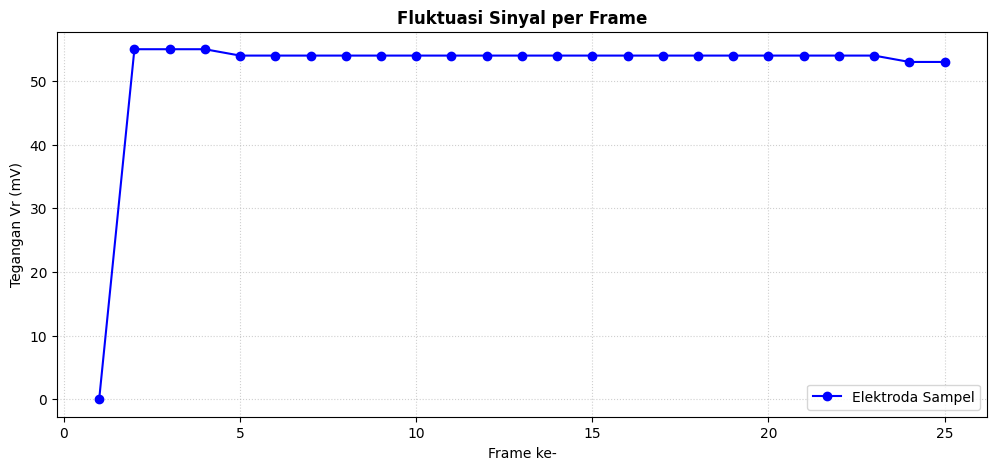

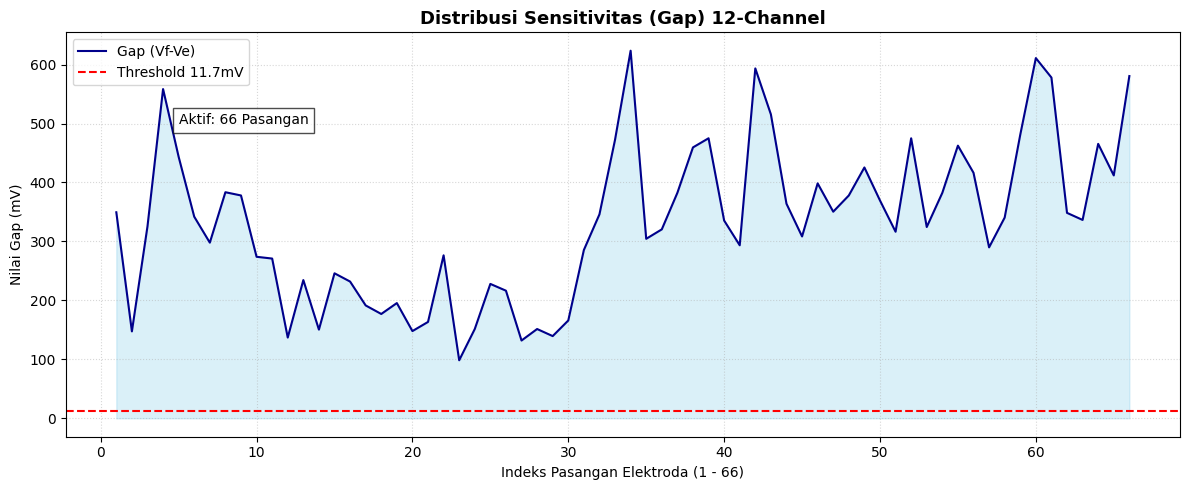

In [7]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. KONFIGURASI FILE
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
THRESHOLD_DEADZONE = 11.7

try:
    # 2. LOAD DATA (Struktur 12-Channel)
    mat_data = scipy.io.loadmat(FILE_PATH)
    bes = mat_data['bes'][0, 0]
    
    # Ekstrak data
    ve_mean = bes['Ve'].flatten()
    vf_mean = bes['Vf'].flatten()
    vrt_frames = bes['Vrt']  # Bentuk: (25 frame, 66 pasangan)
    
    # --- A. ANALISIS STATISTIK ---
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    # Signal Mean (Rata-rata Gap yang valid)
    signal_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
    
    # Temporal Noise (Fluktuasi 25 Frame pada Vrt)
    # vrt_frames axis 0 adalah frame, axis 1 adalah elektroda
    std_per_electrode = np.std(vrt_frames, axis=0) 
    temporal_noise = np.mean(std_per_electrode[mask_alive]) if np.any(mask_alive) else 1e-5

    # SNR Calculation
    snr_db = 20 * np.log10(signal_mean / temporal_noise) if signal_mean > 0 else 0

    stats_result = {
        'System': '12-Channel Das 2',
        'Signal_Mean(mV)': round(signal_mean, 2),
        'Noise_Temporal(mV)': round(temporal_noise, 4),
        'SNR_dB': round(snr_db, 2),
        'Active_Pairs': np.sum(mask_alive)
    }

    # 3. TAMPILKAN TABEL HASIL
    print("\n" + "="*55)
    print("HASIL ANALISIS SNR TEMPORAL (12-CHANNEL)")
    print("="*55)
    print(pd.DataFrame([stats_result]).to_string(index=False))
    print("="*55)

    # 4. VISUALISASI FLUKTUASI (FRAME-BY-FRAME)
    plt.figure(figsize=(12, 5))
    
    # Ambil sampel elektroda pertama yang aktif
    sample_idx = np.where(mask_alive)[0][0] 
    sample_data = vrt_frames[:, sample_idx]
    
    plt.plot(range(1, 26), sample_data, marker='o', color='blue', linewidth=1.5, label='Elektroda Sampel')
    plt.title('Fluktuasi Sinyal per Frame', fontsize=12, fontweight='bold')
    plt.xlabel('Frame ke-')
    plt.ylabel('Tegangan Vr (mV)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

    # 5. VISUALISASI SEBARAN GAP (Subplot diganti jadi Single Plot)
    plt.figure(figsize=(12, 5))
    electrodes = np.arange(1, len(gap) + 1)
    
    plt.plot(electrodes, gap, color='darkblue', linewidth=1.5, label='Gap (Vf-Ve)')
    plt.fill_between(electrodes, gap, color='skyblue', alpha=0.3)
    plt.axhline(y=THRESHOLD_DEADZONE, color='red', linestyle='--', label=f'Threshold {THRESHOLD_DEADZONE}mV')
    
    plt.title('Distribusi Sensitivitas (Gap) 12-Channel', fontsize=13, fontweight='bold')
    plt.xlabel('Indeks Pasangan Elektroda (1 - 66)')
    plt.ylabel('Nilai Gap (mV)')
    plt.text(5, np.max(gap)*0.8, f'Aktif: {stats_result["Active_Pairs"]} Pasangan', 
             bbox=dict(facecolor='white', alpha=0.7))
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

analisis data gabungan


--- MEMPROSES AGREGASI 5 TRIAL (12-CH) ---
Trial 1 sukses.
Trial 2 sukses.
Trial 3 sukses.
Trial 4 sukses.
Trial 5 sukses.

REKAPITULASI FINAL AGREGAT (5 TRIALS)
          Sistem  Avg_Noise_Sigma(mV)  Avg_Peak_Cnorm  RSD_Stability(%)  Avg_SNR(dB)  Avg_Dead_Zones
12-Channel Das 2               1.0593        0.007394            2.0078        49.97             0.0


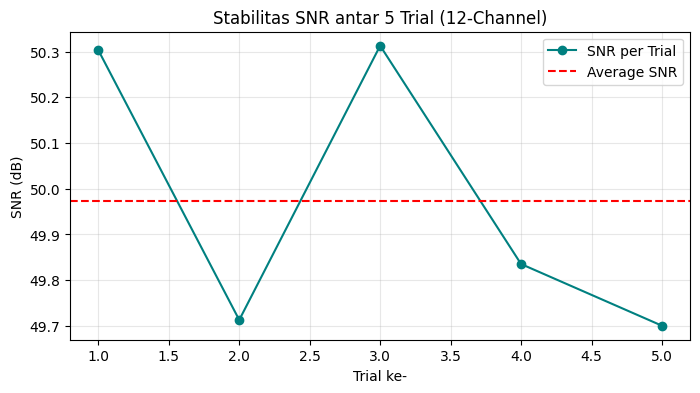

In [8]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. KONFIGURASI
FILE_PATHS = [
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat',
    r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat'
]

THRESHOLD_DEADZONE = 11.7

# 2. PROSES LOADING & PERHITUNGAN
all_stats_collector = [] 

print("--- MEMPROSES AGREGASI 5 TRIAL (12-CH) ---")

for f_idx, path in enumerate(FILE_PATHS):
    try:
        mat = scipy.io.loadmat(path)
        bes = mat['bes'][0, 0]
        
        ve_mean = bes['Ve'].flatten()
        vf_mean = bes['Vf'].flatten()
        vr_mean = np.mean(bes['Vrt'], axis=0)
        vrt_raw = bes['Vrt'] # Data 25 frame untuk hitung noise riil
        
        gap = vf_mean - ve_mean
        is_alive = gap > THRESHOLD_DEADZONE
        
        # Hitung Noise Temporal Riil per Trial (mV)
        sigma_aktual = np.mean(np.std(vrt_raw, axis=0)[is_alive])
        
        # SNR (Voltage Domain)
        signal_power = np.mean(gap[is_alive]) if np.any(is_alive) else 0
        snr_db = 20 * np.log10(signal_power / sigma_aktual) if signal_power > 0 else 0
        
        # Normalisasi Kapasitansi (Peak)
        c_norm = np.zeros(len(gap))
        c_norm[is_alive] = (vr_mean[is_alive] - ve_mean[is_alive]) / gap[is_alive]
        c_norm = np.clip(c_norm, 0, 1)
        
        all_stats_collector.append({
            'snr': snr_db,
            'peak': np.max(c_norm),
            'sigma': sigma_aktual,
            'dead_zones': np.sum(~is_alive)
        })
        print(f"Trial {f_idx+1} sukses.")

    except Exception as e:
        print(f"Error pada Trial {f_idx+1}: {e}")

# 3. AGREGASI FINAL
snr_list = [t['snr'] for t in all_stats_collector]
peak_list = [t['peak'] for t in all_stats_collector]
sigma_list = [t['sigma'] for t in all_stats_collector]
dz_list = [t['dead_zones'] for t in all_stats_collector]

avg_peak = np.mean(peak_list)
std_peak = np.std(peak_list)
rsd_peak = (std_peak / avg_peak) * 100 if avg_peak > 0 else 0

final_summary = {
    'Sistem': '12-Channel Das 2',
    'Avg_Noise_Sigma(mV)': round(np.mean(sigma_list), 4),
    'Avg_Peak_Cnorm': round(avg_peak, 6),
    'RSD_Stability(%)': round(rsd_peak, 4),
    'Avg_SNR(dB)': round(np.mean(snr_list), 2),
    'Avg_Dead_Zones': round(np.mean(dz_list), 2)
}

# 4. OUTPUT HASIL
df_final = pd.DataFrame([final_summary])
print("\n" + "="*70)
print("REKAPITULASI FINAL AGREGAT (5 TRIALS)")
print("="*70)
print(df_final.to_string(index=False))
print("="*70)

# Visualisasi Stabilitas SNR antar Trial
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), snr_list, marker='o', color='teal', label='SNR per Trial')
plt.axhline(y=np.mean(snr_list), color='red', linestyle='--', label='Average SNR')
plt.title('Stabilitas SNR antar 5 Trial (12-Channel)')
plt.xlabel('Trial ke-')
plt.ylabel('SNR (dB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

analisis data gabungan (STD akurat)


In [9]:
import scipy.io
import numpy as np
import pandas as pd
import os

# 1. KONFIGURASI
FOLDER_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan'
FILE_NAMES = [
    'breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat'
]
THRESHOLD_DEADZONE = 11.7

def hitung_snr_temporal_12ch(file_path):
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return None

    mat_data = scipy.io.loadmat(file_path)
    # Akses struktur 'bes' untuk 12-channel
    bes = mat_data['bes'][0, 0]
    
    ve_mean = bes['Ve'].flatten()
    vf_mean = bes['Vf'].flatten()
    vrt_raw = bes['Vrt']  # Bentuk: (25 frame, 66 elektroda)
    
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    sig_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
    
    # Noise dari fluktuasi frame (axis=0 untuk data Vrt 12-ch)
    std_elektroda = np.std(vrt_raw, axis=0)
    noise_temp = np.mean(std_elektroda[mask_alive]) if np.any(mask_alive) else 1e-5
    
    snr_db = 20 * np.log10(sig_mean / noise_temp) if sig_mean > 0 else 0
    return snr_db

# 2. PROSES SEMUA TRIAL
snr_results = []
for file in FILE_NAMES:
    path = os.path.join(FOLDER_PATH, file)
    res = hitung_snr_temporal_12ch(path)
    if res is not None:
        snr_results.append(res)

# 3. REKAPITULASI (Sederhana karena hanya 1 frekuensi)
if snr_results:
    rekap = {
        'Sistem': '12-Channel Das 2',
        'SNR_Avg (dB)': round(np.mean(snr_results), 2),
        'SNR_Std (Stabilitas)': round(np.std(snr_results), 3),
        'Min_SNR': round(np.min(snr_results), 2),
        'Max_SNR': round(np.max(snr_results), 2),
        'Total_Trial': len(snr_results)
    }

    df_final = pd.DataFrame([rekap])
    print("\n=== REKAP SNR GABUNGAN 12-CH (METODE TEMPORAL) ===")
    print(df_final.to_string(index=False))
else:
    print("Tidak ada data yang berhasil diproses.")


=== REKAP SNR GABUNGAN 12-CH (METODE TEMPORAL) ===
          Sistem  SNR_Avg (dB)  SNR_Std (Stabilitas)  Min_SNR  Max_SNR  Total_Trial
12-Channel Das 2         49.97                 0.278     49.7    50.31            5


analisis data gabungan lengkap



TRIAL    | SIGNAL AVG (mV)    | NOISE AVG (mV)     | SNR (dB)     | ACTIVE PAIRS
-----------------------------------------------------------------------------------------------
T1       | 333.7803           | 1.019303           | 50.30        | 66
T2       | 333.7803           | 1.090963           | 49.71        | 66
T3       | 333.7803           | 1.018157           | 50.31        | 66
T4       | 333.7803           | 1.075705           | 49.84        | 66
T5       | 333.7803           | 1.092551           | 49.70        | 66

REKAPITULASI METROLOGI FINAL (RATA-RATA 5 TRIAL)
Avg_Signal(mV)      : 333.7803
Avg_Noise(mV)       : 1.059336
Avg_SNR(dB)         : 49.97
LOD (3-Sigma)       : 3.178
LOQ (10-Sigma)      : 10.5934
Mean Active Pairs   : 66.0


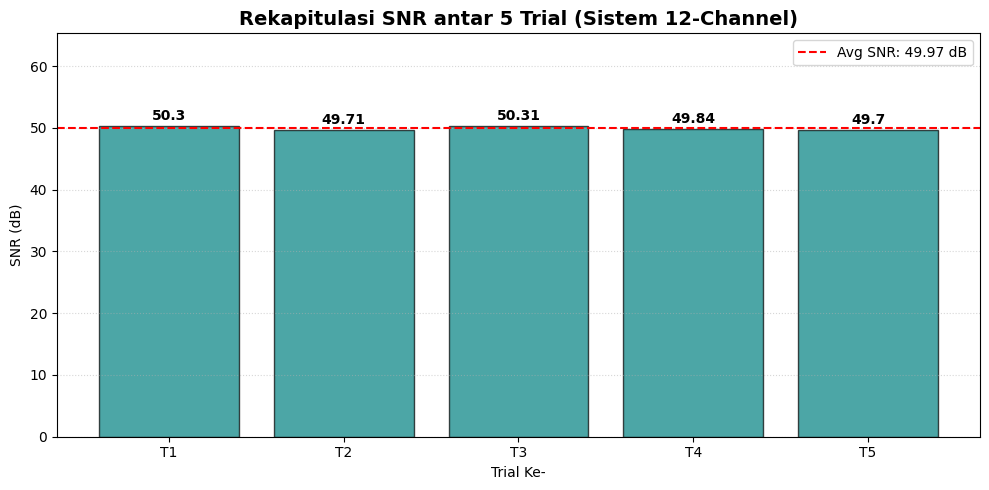

In [10]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. KONFIGURASI FOLDER DAN FILE
# Pastikan folder path ini sesuai dengan lokasi di komputer Anda
FOLDER_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan'
FILE_NAMES = [
    'breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat'
]
THRESHOLD_DEADZONE = 12 # Ambang batas untuk mengabaikan elektroda yang mati/error

def ambil_data_12ch(file_path, trial_name):
    if not os.path.exists(file_path):
        print(f"Peringatan: File {file_path} tidak ditemukan.")
        return None
    
    # Memuat file .dat (format MATLAB)
    mat_data = scipy.io.loadmat(file_path)
    bes = mat_data['bes'][0, 0]
    
    # Ekstrak data dari struct 'bes'
    ve_mean = bes['Ve'].flatten()  # Tegangan Udara (Reference)
    vf_mean = bes['Vf'].flatten()  # Tegangan Air (Full)
    vrt_raw = bes['Vrt']           # Data mentah 25 frame x 66 pasangan
    
    # Hitung Gap (Selisih Tegangan)
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    # Menghitung Signal Mean
    sig_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
    
    # Menghitung Noise Temporal (Sigma aktual dari 25 frame)
    std_per_ch = np.std(vrt_raw, axis=0) # Standar deviasi tiap pasangan elektroda
    noise_temp = np.mean(std_per_ch[mask_alive]) if np.any(mask_alive) else 1e-5
    
    # Menghitung SNR dalam desibel (dB)
    snr_db = 20 * np.log10(sig_mean / noise_temp) if sig_mean > 0 else 0
    
    return {
        'Trial': trial_name,
        'Signal_Mean(mV)': round(sig_mean, 4),
        'Noise_Temp(mV)': round(noise_temp, 6),
        'SNR(dB)': round(snr_db, 2),
        'Active_Pairs': int(np.sum(mask_alive))
    }   

# 2. PROSES PENGUMPULAN DATA PER TRIAL
all_rows = []
print("\n" + "="*95)
print(f"{'TRIAL':<8} | {'SIGNAL AVG (mV)':<18} | {'NOISE AVG (mV)':<18} | {'SNR (dB)':<12} | {'ACTIVE PAIRS'}")
print("-" * 95)

for i, file in enumerate(FILE_NAMES):
    path = os.path.join(FOLDER_PATH, file)
    trial_name = f"T{i+1}"
    data = ambil_data_12ch(path, trial_name)
    
    if data:
        all_rows.append(data)
        # Menampilkan detail langsung per trial
        print(f"{data['Trial']:<8} | {data['Signal_Mean(mV)']:<18.4f} | {data['Noise_Temp(mV)']:<18.6f} | {data['SNR(dB)']:<12.2f} | {data['Active_Pairs']}")

print("="*95)

# 3. PERHITUNGAN REKAPITULASI FINAL DAN METROLOGI
df_all = pd.DataFrame(all_rows)

avg_sigma = df_all['Noise_Temp(mV)'].mean()
avg_signal = df_all['Signal_Mean(mV)'].mean()

rekap = {
    'Avg_Signal(mV)'    : round(avg_signal, 4),
    'Avg_Noise(mV)'     : round(avg_sigma, 6),
    'Avg_SNR(dB)'       : round(df_all['SNR(dB)'].mean(), 2),
    'LOD (3-Sigma)'     : round(3 * avg_sigma, 4),
    'LOQ (10-Sigma)'    : round(10 * avg_sigma, 4),
    'Mean Active Pairs' : round(df_all['Active_Pairs'].mean(), 2)
}

print("\n" + "="*50)
print("REKAPITULASI METROLOGI FINAL (RATA-RATA 5 TRIAL)")
print("="*50)
for k, v in rekap.items():
    print(f"{k:<20}: {v}")
print("="*50)

# 4. VISUALISASI KONSISTENSI SNR
plt.figure(figsize=(10, 5))
bars = plt.bar(df_all['Trial'], df_all['SNR(dB)'], color='teal', edgecolor='black', alpha=0.7)
plt.axhline(y=rekap['Avg_SNR(dB)'], color='red', linestyle='--', label=f"Avg SNR: {rekap['Avg_SNR(dB)']} dB")

# Tambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}', ha='center', fontweight='bold')

plt.title('Rekapitulasi SNR antar 5 Trial (Sistem 12-Channel)', fontsize=14, fontweight='bold')
plt.ylabel('SNR (dB)')
plt.xlabel('Trial Ke-')
plt.ylim(0, max(df_all['SNR(dB)']) + 15)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


TRIAL    | S-SIGNAL AVG       | S-NOISE AVG        | SNR NORM (dB) | ACTIVE PAIRS
-----------------------------------------------------------------------------------------------
T1       | 1.0000             | 0.00500345         | 46.01        | 66
T2       | 1.0000             | 0.00520416         | 45.67        | 66
T3       | 1.0000             | 0.00501838         | 45.99        | 66
T4       | 1.0000             | 0.00528076         | 45.55        | 66
T5       | 1.0000             | 0.00520761         | 45.67        | 66

REKAPITULASI METROLOGI NORMALISASI (FINAL)
Avg_S_Signal        : 1.0
Avg_S_Noise         : 0.00514287
Avg_SNR_Norm (dB)   : 45.78
LOD (3-Sigma S)     : 0.015429
LOQ (10-Sigma S)    : 0.051429
Mean Active Pairs   : 66.0


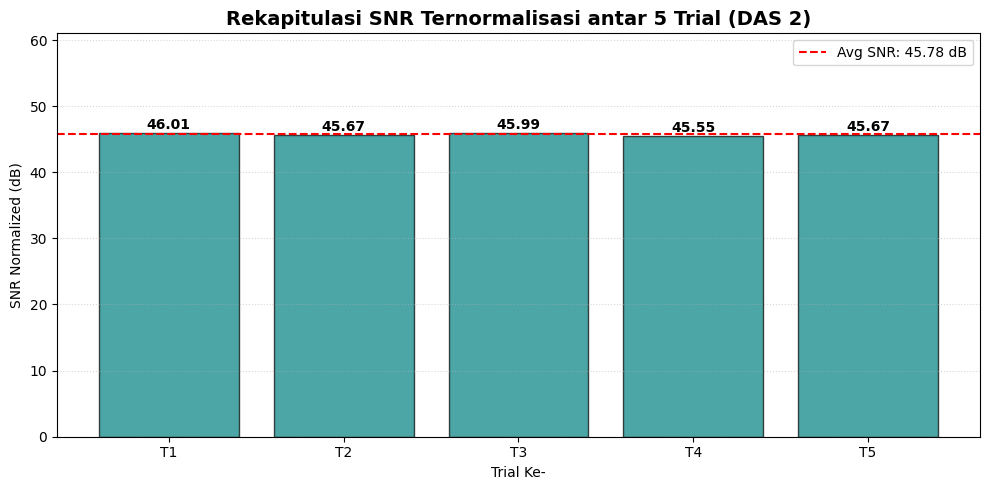

In [3]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. KONFIGURASI FOLDER DAN FILE
FOLDER_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan'
FILE_NAMES = [
    'breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat'
]
THRESHOLD_DEADZONE = 12 

def ambil_data_12ch_normalized(file_path, trial_name):
    if not os.path.exists(file_path):
        print(f"Peringatan: File {file_path} tidak ditemukan.")
        return None
    
    mat_data = scipy.io.loadmat(file_path)
    bes = mat_data['bes'][0, 0]
    
    ve_mean = bes['Ve'].flatten()  
    vf_mean = bes['Vf'].flatten()  
    vrt_raw = bes['Vrt']           
    
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    if np.any(mask_alive):
        # Domain Normalisasi
        sig_norm = 1.0
        std_per_ch = np.std(vrt_raw, axis=0) 
        
        # S-Noise: Noise dibagi Gap per elektroda
        normalized_noise_ch = std_per_ch[mask_alive] / gap[mask_alive]
        avg_s_noise = np.mean(normalized_noise_ch)
        
        snr_norm_db = 20 * np.log10(sig_norm / (avg_s_noise + 1e-9))
        
        return {
            'Trial': trial_name,
            'S_Signal': sig_norm,
            'S_Noise': avg_s_noise,
            'SNR_dB': snr_norm_db,
            'Active_Pairs': int(np.sum(mask_alive))
        }
    return None

# 2. PROSES PENGUMPULAN DATA PER TRIAL (POLA TABEL SEBELUMNYA)
all_rows = []
print("\n" + "="*95)
print(f"{'TRIAL':<8} | {'S-SIGNAL AVG':<18} | {'S-NOISE AVG':<18} | {'SNR NORM (dB)':<12} | {'ACTIVE PAIRS'}")
print("-" * 95)

for i, file in enumerate(FILE_NAMES):
    path = os.path.join(FOLDER_PATH, file)
    trial_name = f"T{i+1}"
    data = ambil_data_12ch_normalized(path, trial_name)
    
    if data:
        all_rows.append(data)
        print(f"{data['Trial']:<8} | {data['S_Signal']:<18.4f} | {data['S_Noise']:<18.8f} | {data['SNR_dB']:<12.2f} | {data['Active_Pairs']}")

print("="*95)

# 3. REKAPITULASI FINAL DAN METROLOGI (POLA SEBELUMNYA)
df_all = pd.DataFrame(all_rows)
avg_s_noise = df_all['S_Noise'].mean()
avg_s_signal = df_all['S_Signal'].mean()

rekap = {
    'Avg_S_Signal'      : round(avg_s_signal, 4),
    'Avg_S_Noise'       : round(avg_s_noise, 8),
    'Avg_SNR_Norm (dB)' : round(df_all['SNR_dB'].mean(), 2),
    'LOD (3-Sigma S)'   : round(3 * avg_s_noise, 6),
    'LOQ (10-Sigma S)'  : round(10 * avg_s_noise, 6),
    'Mean Active Pairs' : round(df_all['Active_Pairs'].mean(), 2)
}

print("\n" + "="*50)
print("REKAPITULASI METROLOGI NORMALISASI (FINAL)")
print("="*50)
for k, v in rekap.items():
    print(f"{k:<20}: {v}")
print("="*50)

# 4. VISUALISASI KONSISTENSI SNR
plt.figure(figsize=(10, 5))
bars = plt.bar(df_all['Trial'], df_all['SNR_dB'], color='teal', edgecolor='black', alpha=0.7)
plt.axhline(y=rekap['Avg_SNR_Norm (dB)'], color='red', linestyle='--', label=f"Avg SNR: {rekap['Avg_SNR_Norm (dB)']} dB")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha='center', fontweight='bold')

plt.title('Rekapitulasi SNR Ternormalisasi antar 5 Trial (DAS 2)', fontsize=14, fontweight='bold')
plt.ylabel('SNR Normalized (dB)')
plt.xlabel('Trial Ke-')
plt.ylim(0, max(df_all['SNR_dB']) + 15)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### RAW DATA


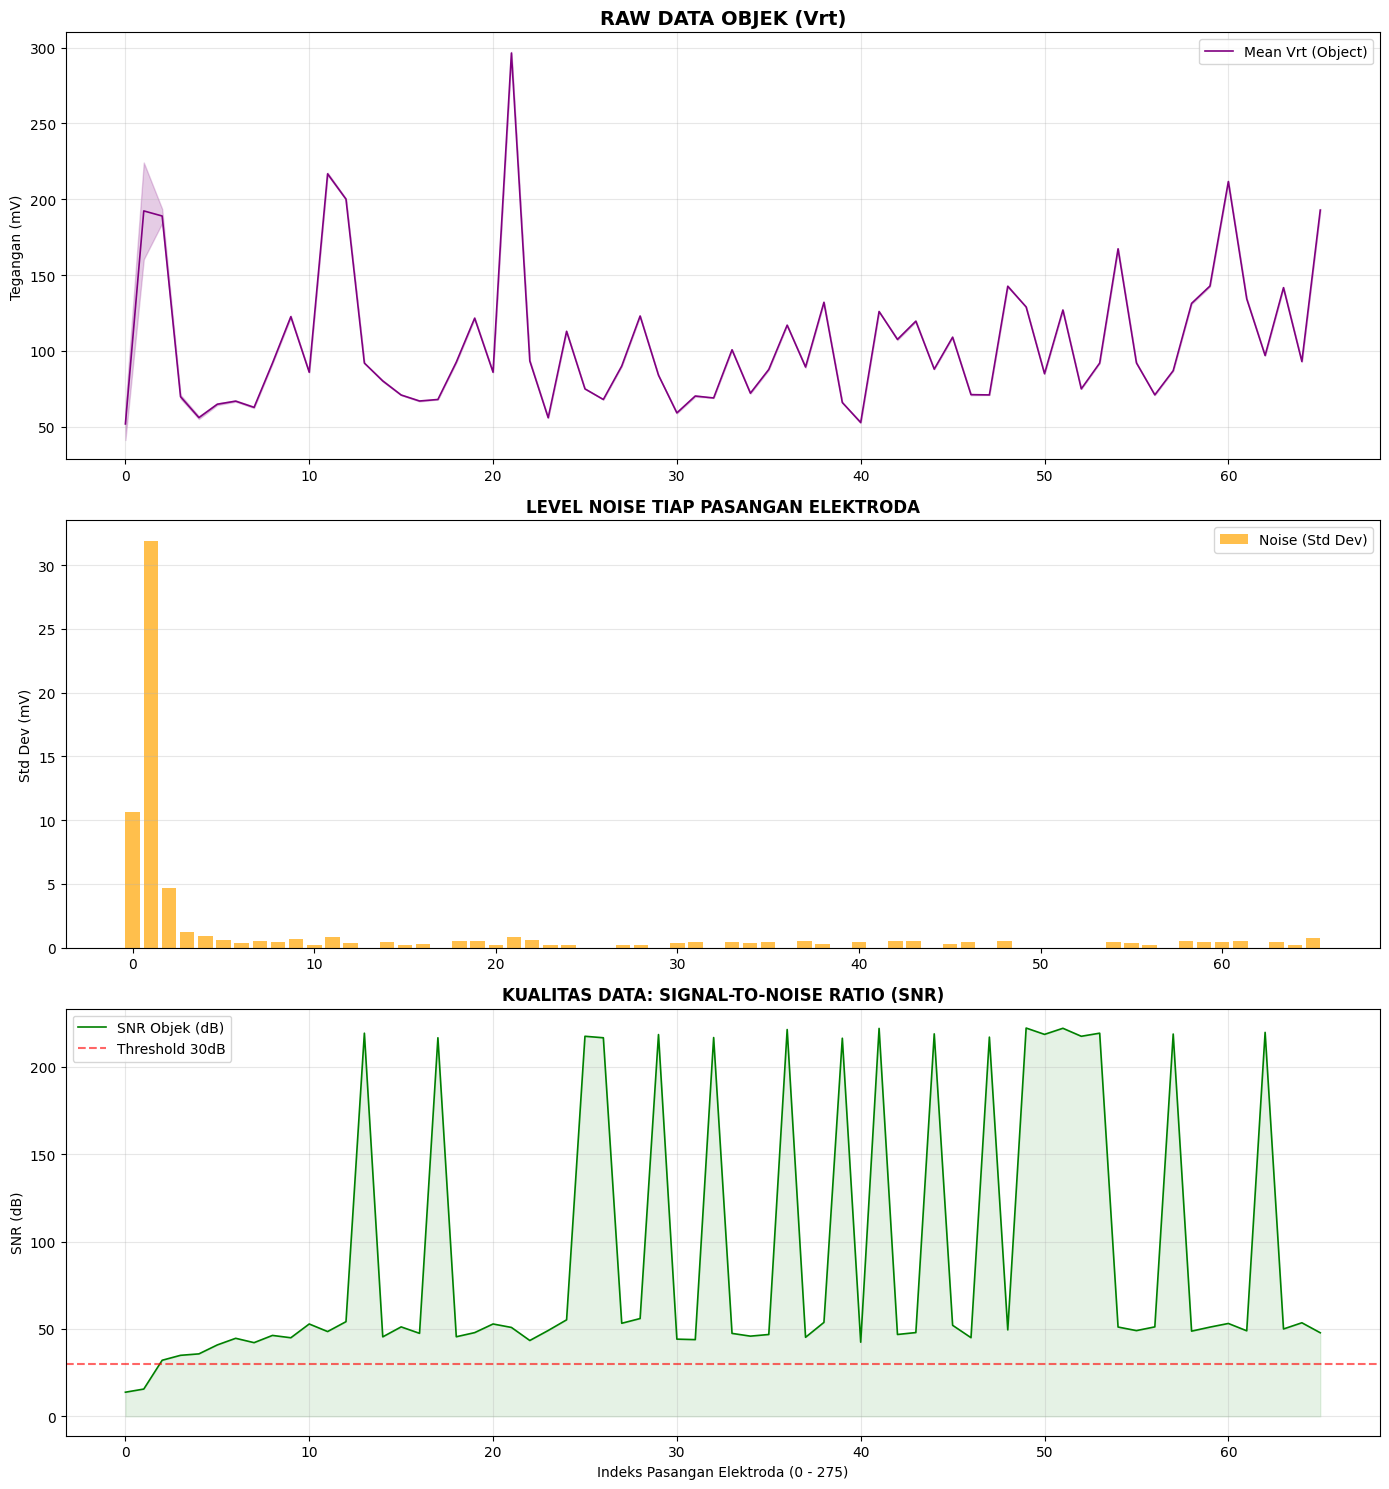

--- RINGKASAN DATA OBJEK (Vrt) ---
Rata-rata SNR   : 93.32 dB
Rata-rata Noise : 1.0193 mV
Jumlah Frame     : 25


In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def plot_full_analysis_das2_vrt(file_path):
    try:
        # 1. Load Data
        mat_data = scipy.io.loadmat(file_path)
        
        # Fokus pada struktur DAS 2
        if 'bes' in mat_data:
            bes = mat_data['bes'][0, 0]
            
            # Mengambil Vrt (Data Real-Time Objek)
            if 'Vrt' in bes.dtype.names:
                # Transpose (.T) dari (25, 276) menjadi (276, 25)
                vr_raw = bes['Vrt'].T 
            else:
                print("Error: Variabel 'Vrt' tidak ditemukan dalam struktur 'bes'.")
                return
        else:
            print("Error: Struktur 'bes' (DAS 2) tidak ditemukan dalam file ini.")
            return

        # 2. Hitung Statistik (Mean, Std, SNR)
        # axis=1 menghitung rata-rata/std antar frame untuk tiap channel
        vr_mean = np.mean(vr_raw, axis=1)
        vr_std = np.std(vr_raw, axis=1)
        
        # Hitung SNR: 20 * log10(Mean / Std)
        with np.errstate(divide='ignore', invalid='ignore'):
            snr_vr = 20 * np.log10(vr_mean / (vr_std + 1e-9))
            snr_vr[~np.isfinite(snr_vr)] = 0

        indices = np.arange(len(vr_mean))

        # 3. Visualisasi (3 Subplots)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))

        # --- Plot A: Profil Tegangan Mentah ---
        ax1.plot(indices, vr_mean, color='purple', linewidth=1.2, label='Mean Vrt (Object)')
        ax1.fill_between(indices, vr_mean - vr_std, vr_mean + vr_std, color='purple', alpha=0.2)
        ax1.set_title('RAW DATA OBJEK (Vrt)', fontweight='bold', fontsize=14)
        ax1.set_ylabel('Tegangan (mV)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        # --- Plot B: Temporal Noise ---
        ax2.bar(indices, vr_std, color='orange', alpha=0.7, label='Noise (Std Dev)')
        ax2.set_title('LEVEL NOISE TIAP PASANGAN ELEKTRODA', fontweight='bold')
        ax2.set_ylabel('Std Dev (mV)')
        ax2.grid(True, axis='y', alpha=0.3)
        ax2.legend()

        # --- Plot C: Signal-to-Noise Ratio (SNR) ---
        ax3.plot(indices, snr_vr, color='green', linewidth=1.2, label='SNR Objek (dB)')
        ax3.fill_between(indices, 0, snr_vr, color='green', alpha=0.1)
        ax3.axhline(y=30, color='red', linestyle='--', alpha=0.6, label='Threshold 30dB')
        ax3.set_title('KUALITAS DATA: SIGNAL-TO-NOISE RATIO (SNR)', fontweight='bold')
        ax3.set_ylabel('SNR (dB)')
        ax3.set_xlabel('Indeks Pasangan Elektroda (0 - 275)')
        ax3.grid(True, alpha=0.3)
        ax3.legend()

        plt.tight_layout()
        plt.show()

        # 4. Ringkasan di Konsol
        print(f"--- RINGKASAN DATA OBJEK (Vrt) ---")
        print(f"Rata-rata SNR   : {np.mean(snr_vr):.2f} dB")
        print(f"Rata-rata Noise : {np.mean(vr_std):.4f} mV")
        print(f"Jumlah Frame     : {vr_raw.shape[1]}")

    except Exception as e:
        print(f"Terjadi Kesalahan: {e}")

# Path ke file DAS 2 Anda
file_path_das2 = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
plot_full_analysis_das2_vrt(file_path_das2)

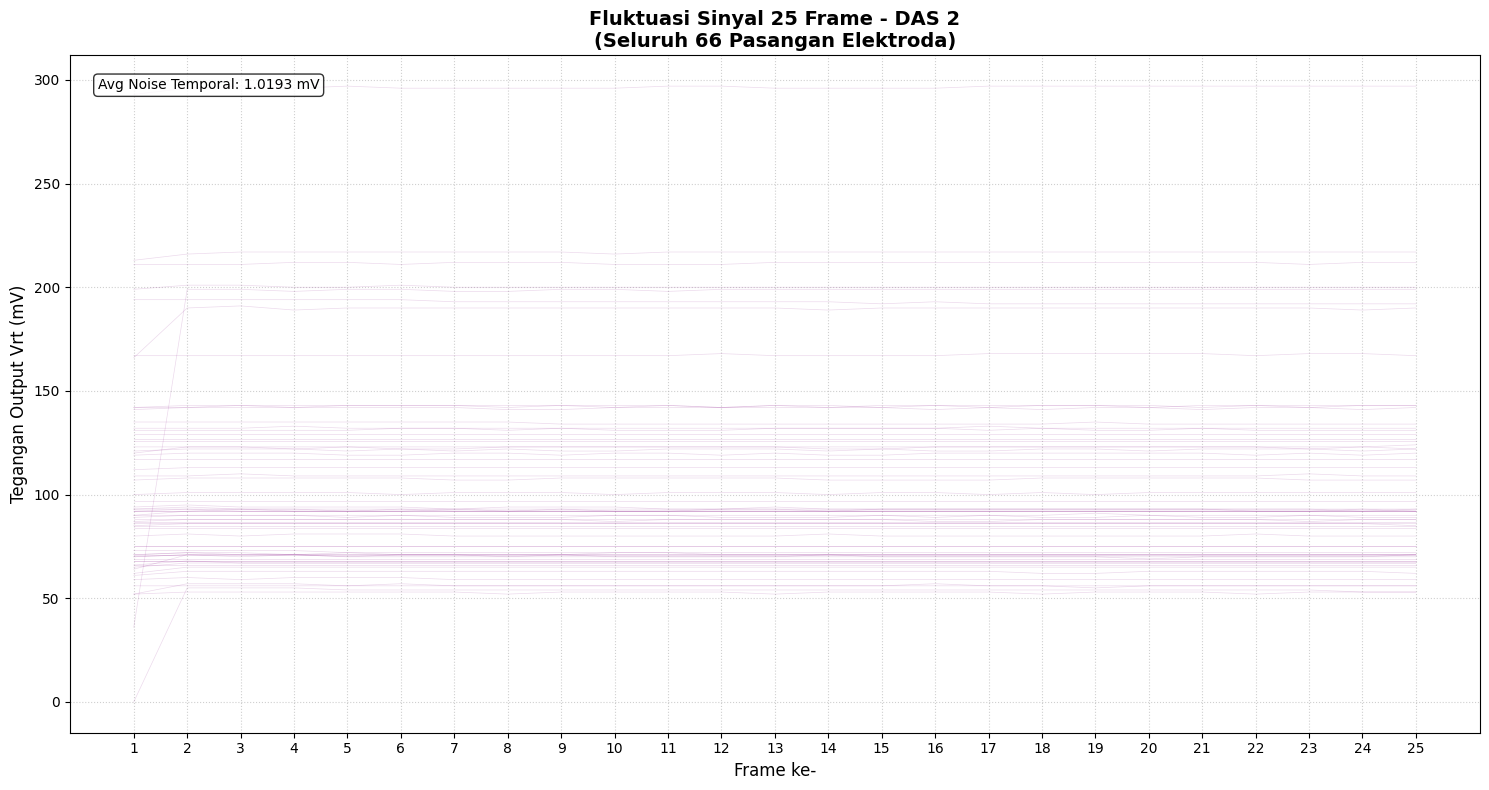

In [4]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. KONFIGURASI FILE
# Pastikan path ini mengarah ke file .dat hasil DAS 2
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
try:
    # 2. LOAD DATA
    mat_data = scipy.io.loadmat(FILE_PATH)
    
    # --- LOGIKA EKSTRAKSI DAS 2 ---
    if 'bes' in mat_data:
        bes = mat_data['bes'][0, 0]
        if 'Vrt' in bes.dtype.names:
            # Data Vrt di DAS 2 biasanya (Frame, Channel) -> misal (25, 276)
            # Kita Transpose (.T) agar menjadi (Channel, Frame) sesuai logika kode Anda
            data_frames = bes['Vrt'].T 
        else:
            print("Error: Variabel 'Vrt' tidak ditemukan dalam struktur 'bes'.")
            exit()
    else:
        print("Error: Struktur 'bes' tidak ditemukan. Ini mungkin bukan file DAS 2.")
        exit()

    num_channels = data_frames.shape[0] 
    num_frames = data_frames.shape[1]   

    # 3. VISUALISASI FLUKTUASI
    plt.figure(figsize=(15, 8))
    frames_range = range(1, num_frames + 1)
    
    # Plot semua pasangan elektroda
    for i in range(num_channels):
        plt.plot(frames_range, data_frames[i, :], color='purple', alpha=0.15, linewidth=0.5)

    # 4. DEKORASI GRAFIK
    # Note: DAS 2 biasanya hanya menggunakan satu frekuensi operasional per file
    plt.title(f'Fluktuasi Sinyal {num_frames} Frame - DAS 2\n(Seluruh {num_channels} Pasangan Elektroda)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Frame ke-', fontsize=12)
    plt.ylabel('Tegangan Output Vrt (mV)', fontsize=12)
    plt.xticks(frames_range)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Statistik Noise Temporal
    total_noise = np.mean(np.std(data_frames, axis=1))
    plt.annotate(f'Avg Noise Temporal: {total_noise:.4f} mV', 
                 xy=(0.02, 0.95), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

    #print(f"Berhasil memproses file DAS 2: {num_channels} channel, {num_frames} frame.")

except Exception as e:
    print(f"Error: {e}")

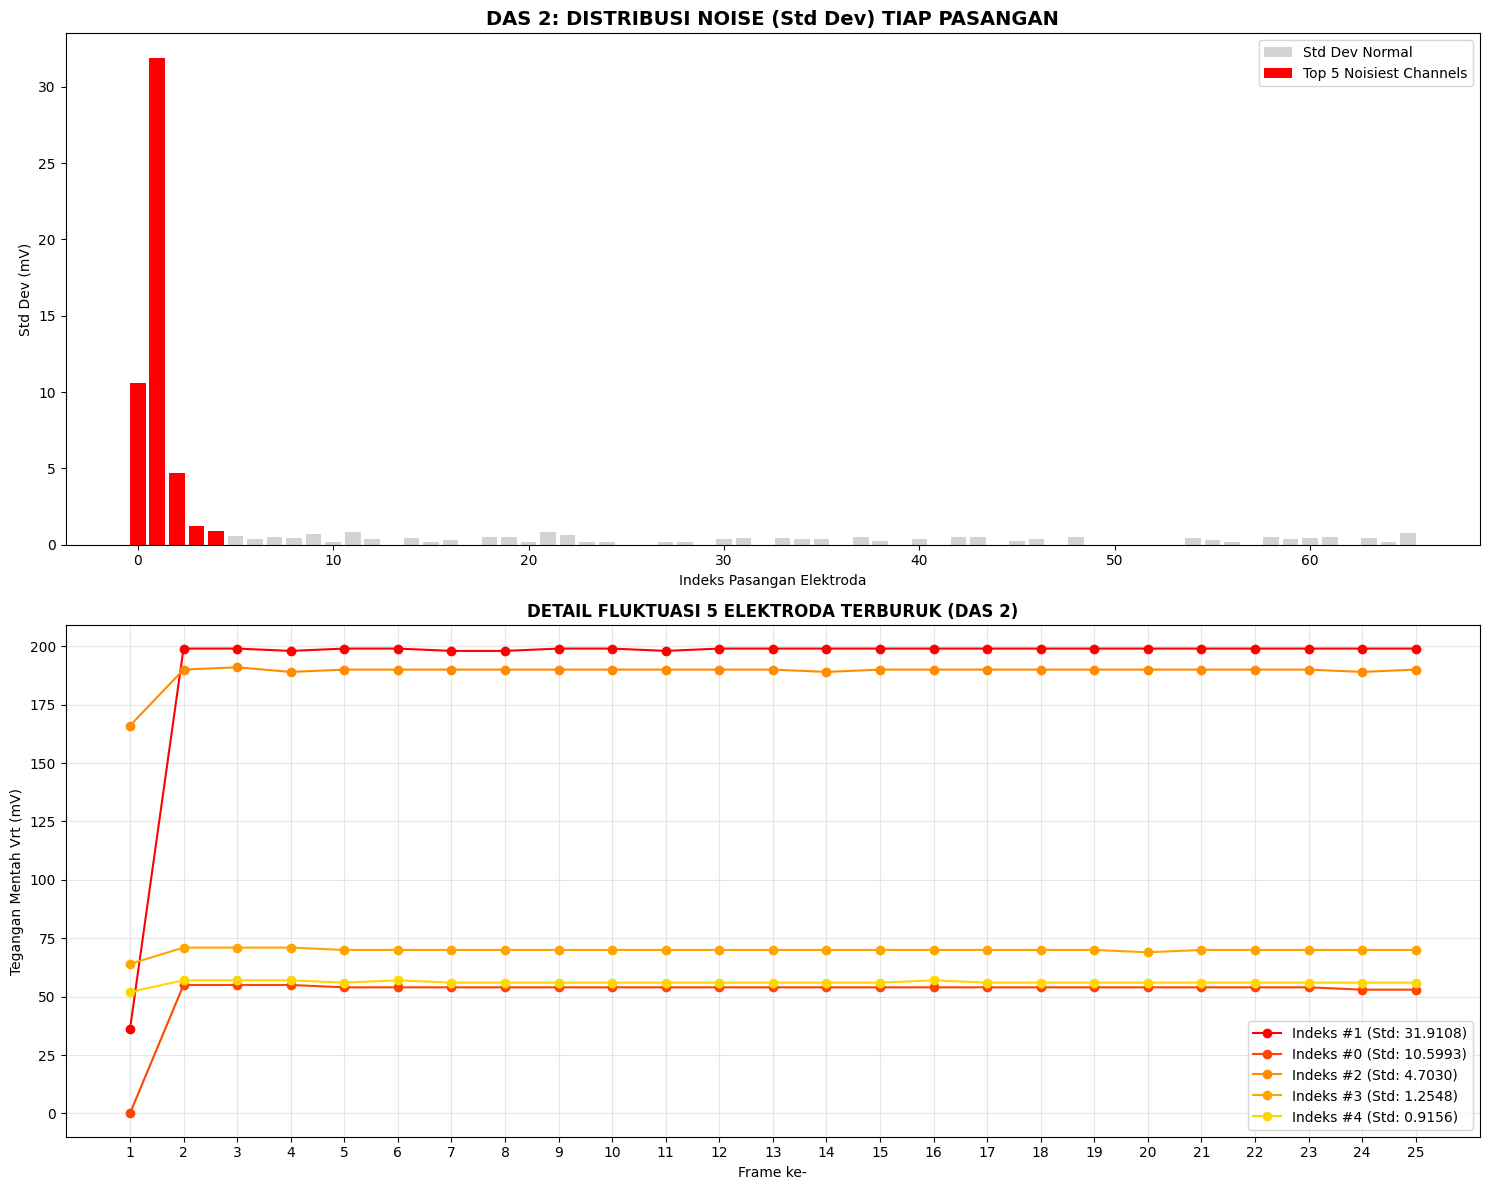


HASIL DETEKSI NOISE DAS 2
1. Pasangan Indeks 1: Std Dev = 31.9108 mV
2. Pasangan Indeks 0: Std Dev = 10.5993 mV
3. Pasangan Indeks 2: Std Dev = 4.7030 mV
4. Pasangan Indeks 3: Std Dev = 1.2548 mV
5. Pasangan Indeks 4: Std Dev = 0.9156 mV
rata-rata Std Dev seluruh elektroda: 1.0193 mV


In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def deteksi_elektroda_liar_das2(file_path):
    try:
        # 1. Load Data
        mat_data = scipy.io.loadmat(file_path)
        
        # --- LOGIKA EKSTRAKSI DAS 2 ---
        if 'bes' in mat_data:
            bes = mat_data['bes'][0, 0]
            if 'Vrt' in bes.dtype.names:
                # DAS 2 menyimpan [Frame, Channel]. 
                # Kita Transpose (.T) agar menjadi [Channel, Frame]
                data_frames = bes['Vrt'].T 
            else:
                print("Error: Variabel 'Vrt' tidak ditemukan dalam struktur 'bes'.")
                return
        else:
            print("Error: Struktur 'bes' tidak ditemukan. Pastikan ini file DAS 2.")
            return

        # 2. Hitung Statistik (Std Dev) per Pasangan
        # axis=1 menghitung variansi antar frame (temporal noise)
        all_std = np.std(data_frames, axis=1)
        
        # Cari 5 indeks dengan Std tertinggi
        top_5_idx = np.argsort(all_std)[-5:][::-1]
        
        # 3. Visualisasi
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

        # --- Plot A: Bar Chart Distribusi Noise ---
        indices = np.arange(len(all_std))
        ax1.bar(indices, all_std, color='lightgray', label='Std Dev Normal')
        ax1.bar(top_5_idx, all_std[top_5_idx], color='red', label='Top 5 Noisiest Channels')
        ax1.set_title('DAS 2: DISTRIBUSI NOISE (Std Dev) TIAP PASANGAN', fontweight='bold', fontsize=14)
        ax1.set_ylabel('Std Dev (mV)')
        ax1.set_xlabel('Indeks Pasangan Elektroda')
        ax1.legend()

        # --- Plot B: Fluktuasi 5 Elektroda Paling Tidak Stabil ---
        num_frames = data_frames.shape[1]
        frames = np.arange(1, num_frames + 1)
        colors = ['#FF0000', '#FF4500', '#FF8C00', '#FFA500', '#FFD700'] 
        
        for i, idx in enumerate(top_5_idx):
            ax2.plot(frames, data_frames[idx, :], marker='o', color=colors[i], 
                     label=f'Indeks #{idx} (Std: {all_std[idx]:.4f})')

        ax2.set_title('DETAIL FLUKTUASI 5 ELEKTRODA TERBURUK (DAS 2)', fontweight='bold')
        ax2.set_xlabel('Frame ke-')
        ax2.set_ylabel('Tegangan Mentah Vrt (mV)')
        ax2.set_xticks(frames)
        ax2.grid(True, alpha=0.3)
        ax2.legend()

        plt.tight_layout()
        plt.show()

        # Print Ringkasan
        print("\n" + "="*45)
        print("HASIL DETEKSI NOISE DAS 2")
        print("="*45)
        for i, idx in enumerate(top_5_idx):
            print(f"{i+1}. Pasangan Indeks {idx}: Std Dev = {all_std[idx]:.4f} mV")
        print("rata-rata Std Dev seluruh elektroda: {:.4f} mV".format(np.mean(all_std)))
        print("="*45)

    except Exception as e:
        print(f"Kesalahan: {e}")

# Masukkan path file DAS 2 Anda di sini
FILE_PATH_DAS2 = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
deteksi_elektroda_liar_das2(FILE_PATH_DAS2)


HASIL ANALISIS SNR TEMPORAL (12-CHANNEL)
          System  Signal_Mean(mV)  Noise_Temporal(mV)  SNR_dB  Active_Pairs
12-Channel Das 2           333.78              1.0193    50.3            66


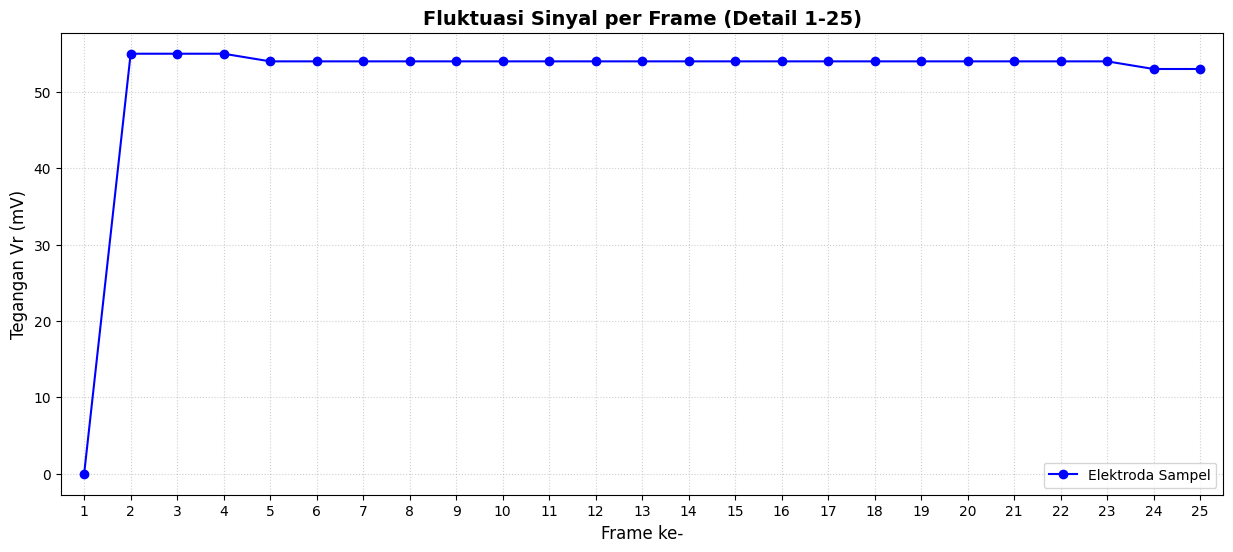

In [6]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. KONFIGURASI FILE
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
THRESHOLD_DEADZONE = 11.7

try:
    # 2. LOAD DATA (Struktur 12-Channel)
    mat_data = scipy.io.loadmat(FILE_PATH)
    bes = mat_data['bes'][0, 0]
    
    # Ekstrak data
    ve_mean = bes['Ve'].flatten()
    vf_mean = bes['Vf'].flatten()
    vrt_frames = bes['Vrt']  # Bentuk: (25 frame, 66 pasangan)
    
    # --- A. ANALISIS STATISTIK ---
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    # Signal Mean (Rata-rata Gap yang valid)
    signal_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
    
    # Temporal Noise (Fluktuasi 25 Frame pada Vrt)
    # vrt_frames axis 0 adalah frame, axis 1 adalah elektroda
    std_per_electrode = np.std(vrt_frames, axis=0) 
    temporal_noise = np.mean(std_per_electrode[mask_alive]) if np.any(mask_alive) else 1e-5

    # SNR Calculation
    snr_db = 20 * np.log10(signal_mean / temporal_noise) if signal_mean > 0 else 0

    stats_result = {
        'System': '12-Channel Das 2',
        'Signal_Mean(mV)': round(signal_mean, 2),
        'Noise_Temporal(mV)': round(temporal_noise, 4),
        'SNR_dB': round(snr_db, 2),
        'Active_Pairs': np.sum(mask_alive)
    }

    # 3. TAMPILKAN TABEL HASIL
    print("\n" + "="*55)
    print("HASIL ANALISIS SNR TEMPORAL (12-CHANNEL)")
    print("="*55)
    print(pd.DataFrame([stats_result]).to_string(index=False))
    print("="*55)

    # 5. VISUALISASI SEBARAN GAP (Subplot diganti jadi Single Plot)
    plt.figure(figsize=(15, 6)) # Ukuran diperlebar agar angka tidak berhimpit
    
    # Ambil sampel elektroda pertama yang aktif
    sample_idx = np.where(mask_alive)[0][0] 
    sample_data = vrt_frames[:, sample_idx]
    
    plt.plot(range(1, 26), sample_data, marker='o', color='blue', linewidth=1.5, label='Elektroda Sampel')
    
    # --- MODIFIKASI DISINI ---
    plt.title('Fluktuasi Sinyal per Frame (Detail 1-25)', fontsize=14, fontweight='bold')
    plt.xlabel('Frame ke-', fontsize=12)
    plt.ylabel('Tegangan Vr (mV)', fontsize=12)
    
    # Menampilkan angka 1 sampai 25 secara eksplisit
    plt.xticks(np.arange(1, 26)) 
    
    # Menambahkan batas sumbu X agar tidak terlalu mepet
    plt.xlim(0.5, 25.5) 
    # -------------------------

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error: {e}")


HASIL ANALISIS SNR TEMPORAL DAS 2 (FRAME 2-25)
Signal Mean    : 333.78 mV
Temporal Noise : 0.2496 mV (Indeks 1-akhir)
SNR            : 62.53 dB
Jumlah Frame   : 24 (Frame 1 dibuang)
Elektroda Aktif: 66


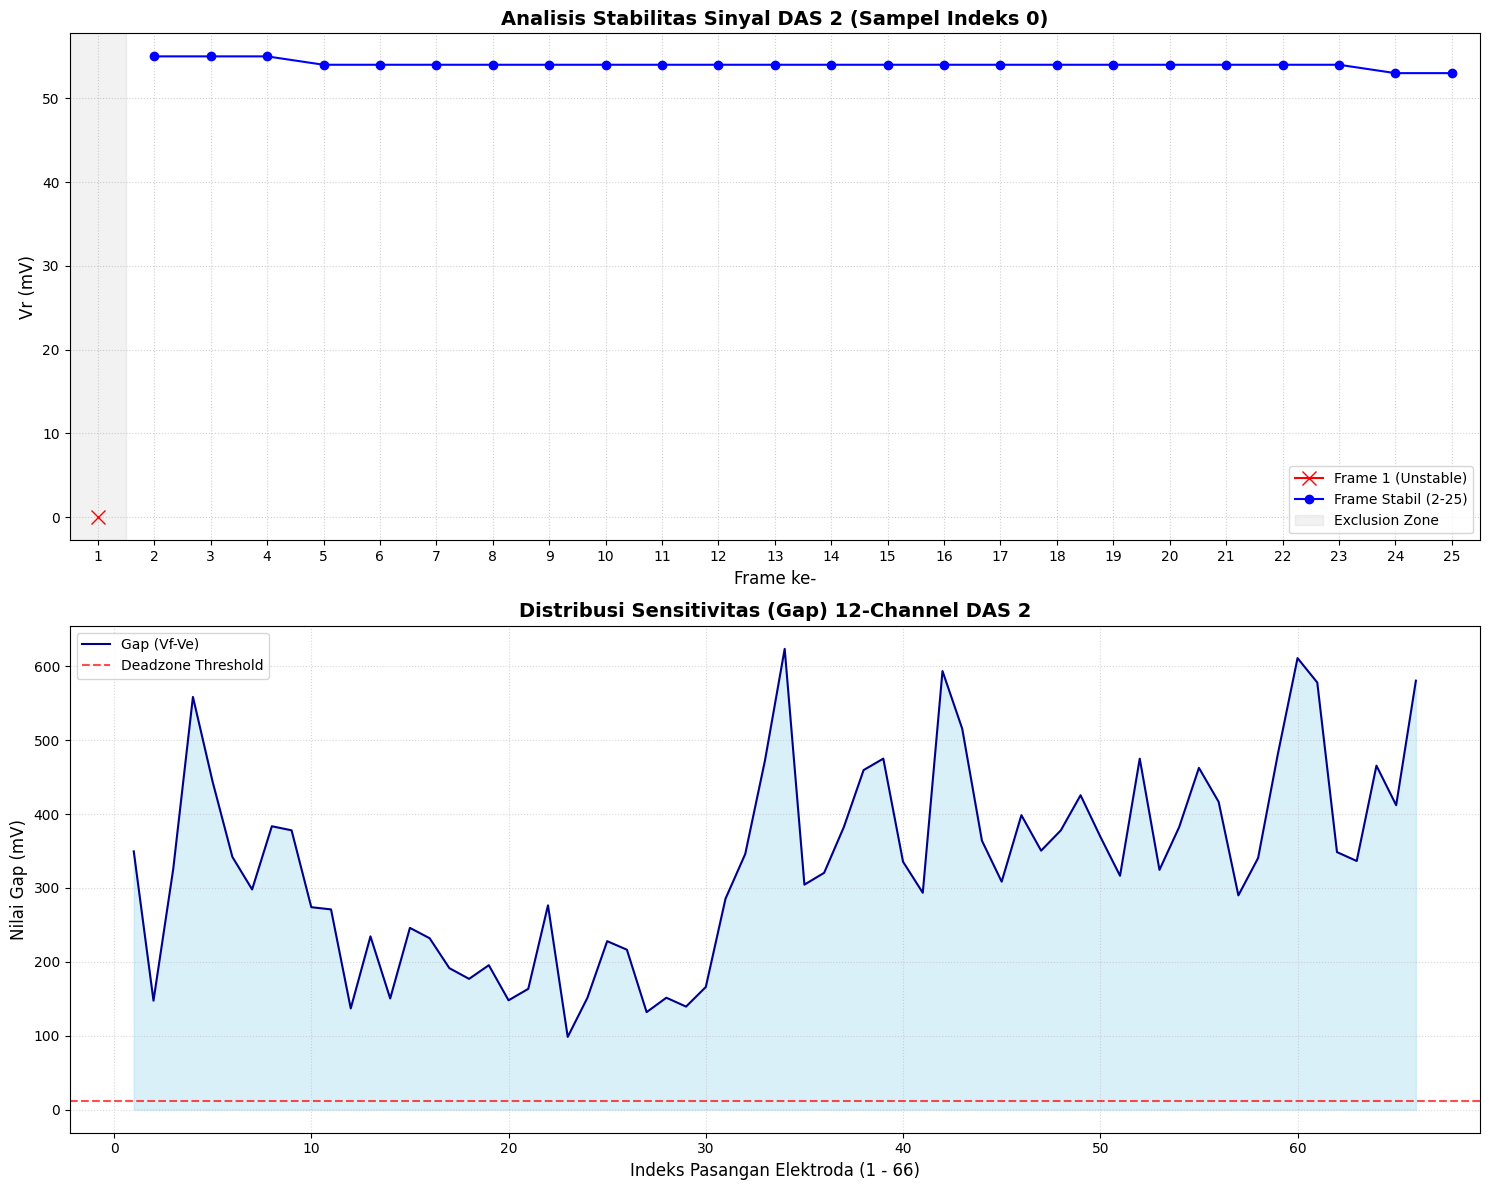

In [7]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. KONFIGURASI FILE
FILE_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan\breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat'
THRESHOLD_DEADZONE = 11.7

try:
    # 2. LOAD DATA (Struktur DAS 2)
    mat_data = scipy.io.loadmat(FILE_PATH)
    bes = mat_data['bes'][0, 0]
    
    # Ekstrak data sesuai struktur DAS 2
    ve_mean = bes['Ve'].flatten()
    vf_mean = bes['Vf'].flatten()
    vrt_frames_all = bes['Vrt']  # Bentuk: (25 frame, 66 pasangan)
    
    # --- A. ANALISIS STATISTIK (Hanya Frame 2 ke atas) ---
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    # Signal Mean (Rata-rata Gap pada elektroda aktif)
    signal_mean = np.mean(gap[mask_alive]) if np.any(mask_alive) else 0
    
    # SLICING: Mengambil frame indeks 1 sampai akhir (Frame 2 - 25)
    vrt_stable = vrt_frames_all[1:, :] 
    
    # Hitung noise temporal hanya dari frame stabil
    # axis=0 karena pada DAS 2 Vrt baris adalah frame
    std_per_electrode = np.std(vrt_stable, axis=0) 
    temporal_noise = np.mean(std_per_electrode[mask_alive]) if np.any(mask_alive) else 1e-5

    # SNR Calculation
    snr_db = 20 * np.log10(signal_mean / temporal_noise) if signal_mean > 0 else 0

    # Tampilkan Ringkasan di Konsol
    print("\n" + "="*55)
    print("HASIL ANALISIS SNR TEMPORAL DAS 2 (FRAME 2-25)")
    print("="*55)
    print(f"Signal Mean    : {signal_mean:.2f} mV")
    print(f"Temporal Noise : {temporal_noise:.4f} mV (Indeks 1-akhir)")
    print(f"SNR            : {snr_db:.2f} dB")
    print(f"Jumlah Frame   : {vrt_stable.shape[0]} (Frame 1 dibuang)")
    print(f"Elektroda Aktif: {np.sum(mask_alive)}")
    print("="*55)

    # --- B. VISUALISASI ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    # Plot 1: Fluktuasi Frame-by-Frame
    sample_idx = np.where(mask_alive)[0][0] 
    sample_data_full = vrt_frames_all[:, sample_idx]
    
    # Plot area tidak stabil (Frame 1)
    ax1.plot(1, sample_data_full[0], marker='x', color='red', markersize=10, label='Frame 1 (Unstable)')
    
    # Plot area stabil (Frame 2-25)
    ax1.plot(range(2, 26), sample_data_full[1:], marker='o', color='blue', linewidth=1.5, label='Frame Stabil (2-25)')
    
    ax1.set_title(f'Analisis Stabilitas Sinyal DAS 2 (Sampel Indeks {sample_idx})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Frame ke-', fontsize=12)
    ax1.set_ylabel('Vr (mV)', fontsize=12)
    ax1.set_xticks(np.arange(1, 26))
    ax1.set_xlim(0.5, 25.5)
    ax1.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Exclusion Zone') # Arsir frame 1
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # Plot 2: Distribusi Gap
    electrodes = np.arange(1, len(gap) + 1)
    ax2.plot(electrodes, gap, color='darkblue', linewidth=1.5, label='Gap (Vf-Ve)')
    ax2.fill_between(electrodes, gap, color='skyblue', alpha=0.3)
    ax2.axhline(y=THRESHOLD_DEADZONE, color='red', linestyle='--', alpha=0.7, label='Deadzone Threshold')
    
    ax2.set_title('Distribusi Sensitivitas (Gap) 12-Channel DAS 2', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Indeks Pasangan Elektroda (1 - 66)', fontsize=12)
    ax2.set_ylabel('Nilai Gap (mV)', fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Terjadi Kesalahan: {e}")


TRIAL    | S-SIGNAL   | S-NOISE AVG     | SNR NORM (dB)   | PAIRS    | FRAMES
--------------------------------------------------------------------------------------------------------------
T1       | 1.0000     | 0.00080678      | 61.86           | 66       | 23
T2       | 1.0000     | 0.00099791      | 60.02           | 66       | 23
T3       | 1.0000     | 0.00075210      | 62.47           | 66       | 23
T4       | 1.0000     | 0.00105123      | 59.57           | 66       | 23
T5       | 1.0000     | 0.00093203      | 60.61           | 66       | 23

REKAPITULASI METROLOGI NORMALISASI (FINAL)
Pesan: Frame 1-2 dibuang untuk kestabilan.
Avg_S_Signal        : 1.0
Avg_S_Noise         : 0.00090801
Avg_SNR_Norm (dB)   : 60.91
LOD (3-Sigma S)     : 0.002724
LOQ (10-Sigma S)    : 0.00908
Mean Active Pairs   : 66.0


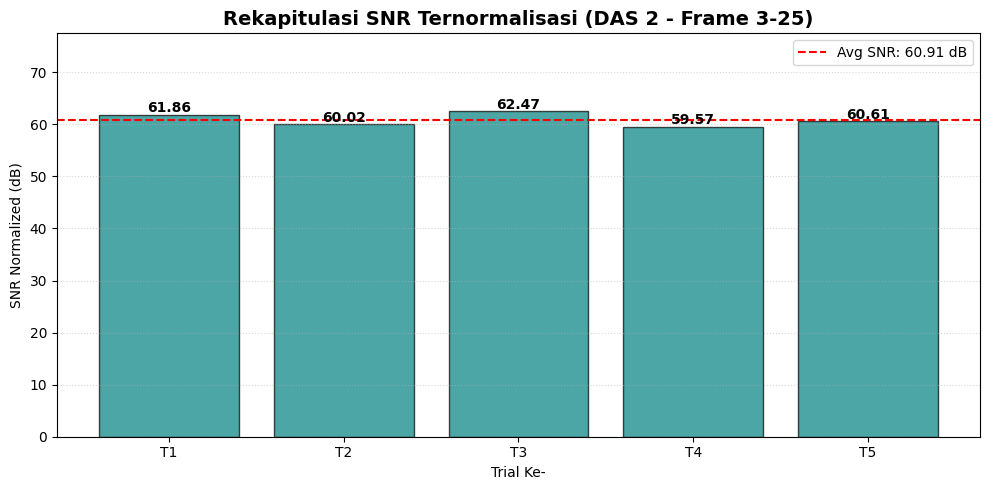

In [1]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. KONFIGURASI FOLDER DAN FILE
FOLDER_PATH = r'C:\Users\ASUS\Documents\KP CTECH\KP UGM - UNS (Tiara, Riris, Rizal)\BREAST ECVT\pengambilan data\4. 12ch Das 2\objek_udara_01_21 Jan'
FILE_NAMES = [
    'breast_12ch_das2_udara_1_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_2_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_3_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_4_dex_planar12ch_21-Jan-2026.dat',
    'breast_12ch_das2_udara_5_dex_planar12ch_21-Jan-2026.dat'
]
THRESHOLD_DEADZONE = 12 

def ambil_data_12ch_normalized(file_path, trial_name):
    if not os.path.exists(file_path):
        print(f"Peringatan: File {file_path} tidak ditemukan.")
        return None
    
    mat_data = scipy.io.loadmat(file_path)
    bes = mat_data['bes'][0, 0]
    
    ve_mean = bes['Ve'].flatten()  
    vf_mean = bes['Vf'].flatten()  
    
    # --- PROSES CUT FRAME ---
    # vrt_raw semula [Frame, Channel]
    # Kita ambil mulai dari indeks ke-2 (Frame ke-3) sampai terakhir
    vrt_raw_full = bes['Vrt']
    vrt_stable = vrt_raw_full[2:, :] # Slicing axis 0 (Frame)
    
    gap = vf_mean - ve_mean
    mask_alive = gap > THRESHOLD_DEADZONE
    
    if np.any(mask_alive):
        # Domain Normalisasi
        sig_norm = 1.0
        
        # Hitung Standard Deviasi hanya dari frame yang sudah stabil (vrt_stable)
        std_per_ch = np.std(vrt_stable, axis=0) 
        
        # S-Noise: Noise dibagi Gap per elektroda
        normalized_noise_ch = std_per_ch[mask_alive] / gap[mask_alive]
        avg_s_noise = np.mean(normalized_noise_ch)
        
        snr_norm_db = 20 * np.log10(sig_norm / (avg_s_noise + 1e-9))
        
        return {
            'Trial': trial_name,
            'S_Signal': sig_norm,
            'S_Noise': avg_s_noise,
            'SNR_dB': snr_norm_db,
            'Active_Pairs': int(np.sum(mask_alive)),
            'Frames_Used': vrt_stable.shape[0]
        }
    return None

# 2. PROSES PENGUMPULAN DATA PER TRIAL
all_rows = []
print("\n" + "="*110)
print(f"{'TRIAL':<8} | {'S-SIGNAL':<10} | {'S-NOISE AVG':<15} | {'SNR NORM (dB)':<15} | {'PAIRS':<8} | {'FRAMES'}")
print("-" * 110)

for i, file in enumerate(FILE_NAMES):
    path = os.path.join(FOLDER_PATH, file)
    trial_name = f"T{i+1}"
    data = ambil_data_12ch_normalized(path, trial_name)
    
    if data:
        all_rows.append(data)
        print(f"{data['Trial']:<8} | {data['S_Signal']:<10.4f} | {data['S_Noise']:<15.8f} | {data['SNR_dB']:<15.2f} | {data['Active_Pairs']:<8} | {data['Frames_Used']}")

print("="*110)

# 3. REKAPITULASI FINAL
df_all = pd.DataFrame(all_rows)
if not df_all.empty:
    avg_s_noise = df_all['S_Noise'].mean()
    avg_s_signal = df_all['S_Signal'].mean()

    rekap = {
        'Avg_S_Signal'      : round(avg_s_signal, 4),
        'Avg_S_Noise'       : round(avg_s_noise, 8),
        'Avg_SNR_Norm (dB)' : round(df_all['SNR_dB'].mean(), 2),
        'LOD (3-Sigma S)'   : round(3 * avg_s_noise, 6),
        'LOQ (10-Sigma S)'  : round(10 * avg_s_noise, 6),
        'Mean Active Pairs' : round(df_all['Active_Pairs'].mean(), 2)
    }

    print("\n" + "="*50)
    print("REKAPITULASI METROLOGI NORMALISASI (FINAL)")
    print("Pesan: Frame 1-2 dibuang untuk kestabilan.")
    print("="*50)
    for k, v in rekap.items():
        print(f"{k:<20}: {v}")
    print("="*50)

    # 4. VISUALISASI
    plt.figure(figsize=(10, 5))
    bars = plt.bar(df_all['Trial'], df_all['SNR_dB'], color='teal', edgecolor='black', alpha=0.7)
    plt.axhline(y=rekap['Avg_SNR_Norm (dB)'], color='red', linestyle='--', label=f"Avg SNR: {rekap['Avg_SNR_Norm (dB)']} dB")

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha='center', fontweight='bold')

    plt.title('Rekapitulasi SNR Ternormalisasi (DAS 2 - Frame 3-25)', fontsize=14, fontweight='bold')
    plt.ylabel('SNR Normalized (dB)')
    plt.xlabel('Trial Ke-')
    plt.ylim(0, max(df_all['SNR_dB']) + 15)
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Data tidak ditemukan untuk diproses.")